<div style="background-color: #C82909; 
            border-radius: 50px; 
            padding: 10px; 
            text-align: center; 
            font-family: 'Times New Roman', serif; 
            font-size: 30px; 
            color: white; 
            font-weight: normal;
            width: 80%;
            margin: auto;">
    Libraries And Utilities
</div>

<br>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [78]:
# Loading Data
df_netflix = pd.read_csv('data/netflix_titles.csv')

<br>

<div style="background-color: #C82909; 
            border-radius: 50px; 
            padding: 10px; 
            text-align: center; 
            font-family: 'Times New Roman', serif; 
            font-size: 30px; 
            color: white; 
            font-weight: normal;
            width: 80%;
            margin: auto;">
    Data Manipulation
</div>

<br>

## Missing Data Analysis
This section examines both the number and percentage of missing values before cleaning.

In [6]:
# Missing Data Counts
df_netflix.isnull().sum().sort_values(ascending = False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [7]:
# Missing Data Rates
for column in df_netflix.columns:
    null_rate = ( df_netflix[column].isnull().sum() / len(df_netflix) ) * 100
    if null_rate > 0:
        print(f"{column} null rate : {null_rate.round(2)}")

director null rate : 29.91
cast null rate : 9.37
country null rate : 9.44
date_added null rate : 0.11
rating null rate : 0.05
duration null rate : 0.03


## Dealing with the missing data

In [8]:
# Replace null data 
df_netflix.replace({'director' : np.nan} , 'No Data' , inplace = True)
df_netflix.replace({'cast' : np.nan} , 'No Data' , inplace = True)

# Fill null data 
df_netflix['country'] = df_netflix['country'].fillna(df_netflix['country'].mode()[0])

In [9]:
# Get the most common value in the rating and fill the null by it

df_netflix['rating'].mode() # series data

# Convert from series to string
rating_mode = ''.join(df_netflix['rating'].mode())

# Fill the null data by rating_mode
df_netflix['rating'] = df_netflix['rating'].fillna(rating_mode)

In [10]:
# Drop null data
df_netflix.dropna(inplace = True)

# Drop duplicted data
df_netflix.drop_duplicates(inplace = True)

## Dataset Structure
The following output shows data types, non-null counts, and dataset size.

In [12]:
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8794 non-null   object
 1   type          8794 non-null   object
 2   title         8794 non-null   object
 3   director      8794 non-null   object
 4   cast          8794 non-null   object
 5   country       8794 non-null   object
 6   date_added    8794 non-null   object
 7   release_year  8794 non-null   int64 
 8   rating        8794 non-null   object
 9   duration      8794 non-null   object
 10  listed_in     8794 non-null   object
 11  description   8794 non-null   object
dtypes: int64(1), object(11)
memory usage: 893.1+ KB


## Handling the date 

In [79]:
# Strip the whitespace from date_added column
df_netflix['date_added'] = df_netflix['date_added'].str.strip()

# Convert date_added column to datetime 
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'])

df_netflix['day_added'] = df_netflix['date_added'].dt.day
df_netflix['month_added'] = df_netflix['date_added'].dt.month
df_netflix['year_added'] = df_netflix['date_added'].dt.year

In [16]:
# make two new dataset for each category
df_movies = df_netflix[ df_netflix['type'] == 'Movie' ]
df_Tv_show = df_netflix[ df_netflix['type'] == 'TV Show' ]

<br>

<div style="background-color: #C82909; 
            border-radius: 50px; 
            padding: 10px; 
            text-align: center; 
            font-family: 'Times New Roman', serif; 
            font-size: 30px; 
            color: white; 
            font-weight: normal;
            width: 80%;
            margin: auto;">
    Data Visualization
</div>

<br>

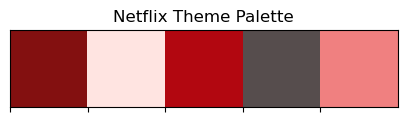

In [15]:
# Palette
netflix_palette1 = ['#470000', '#750000','#A30000','#D10000','#FF0000' ,
                    '#FF2E2E' ,'#FF5C5C','#FF8A8A','#FFB8B8','#FFE6E6']
netflix_palette2 = ['#831010','mistyrose','#b20710','#564d4d','LightCoral']
sns.palplot(netflix_palette2)
plt.title('Netflix Theme Palette')
plt.show()

## Netflix Content Type Analysis
This section identifies the count of netflix content for each type.

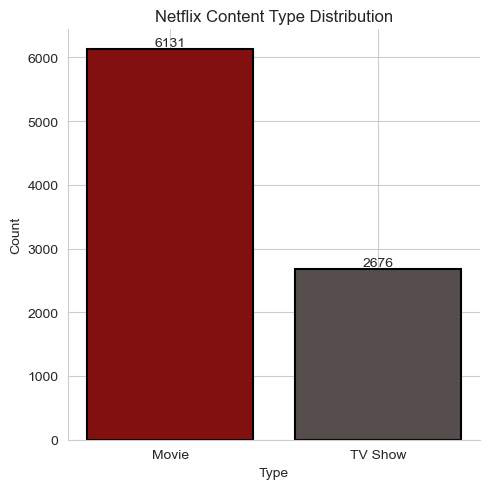

In [81]:
type_count = df_netflix['type'].value_counts()

fig , ax = plt.subplots(1,1 , figsize = (5,5))

bars = ax.bar(type_count.index ,type_count.values ,
              color = ['#831010','#564d4d'],linewidth=1.5,edgecolor = 'black')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2 ,
            height ,str(height),ha = 'center' ,va='bottom')

ax.spines['top'].set_color('None')
ax.spines['right'].set_color('None')

ax.set_xlabel('Type')
ax.set_ylabel('Count')
ax.set_title('Netflix Content Type Distribution')

plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

### Insight
Movies dominate Netflix library with almost double TV Shows

## Top Countries Analysis
This section identifies countries producing the most Netflix content.

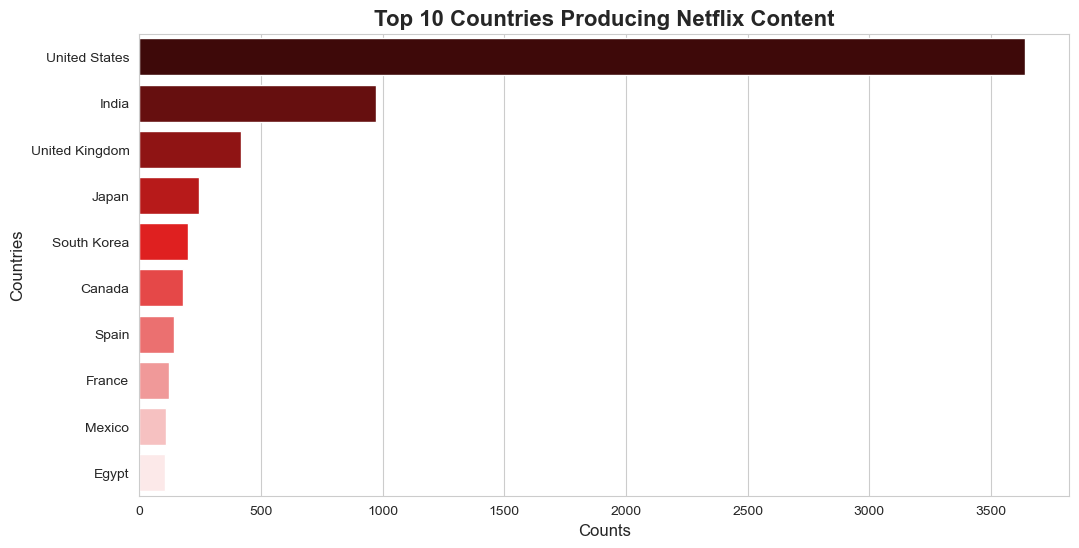

In [60]:
# Get top 10 countries in production
top_countries = df_netflix['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(x = top_countries.values , y = top_countries.index , palette = netflix_palette1)

plt.title('Top 10 Countries Producing Netflix Content' , fontsize = 16 , fontweight = 'bold')
plt.xlabel('Counts' , fontsize = 12)
plt.ylabel('Countries' , fontsize = 12)

plt.show()

### Insight
USA produces the most Netflix content

## Netflix content Through years Analysis
This section identifies when content in netflix increased rapidly.

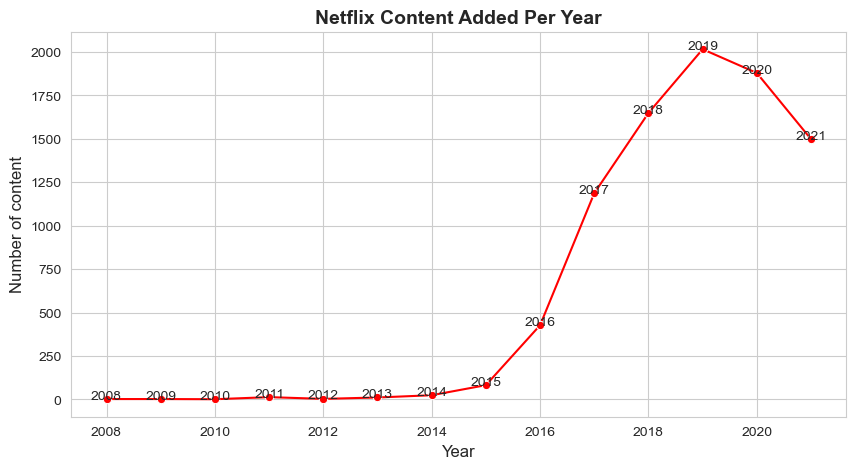

In [61]:
# Get Netflix Content through years
content_per_year = df_netflix['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x = content_per_year.index, y= content_per_year.values , marker = 'o' , color = 'red')

for x, y in zip(content_per_year.index, content_per_year.values):
    plt.text(x, y, str(x), ha='center')

plt.title('Netflix Content Added Per Year', fontsize = 14 , fontweight = 'bold')
plt.xlabel('Year' , fontsize = 12)
plt.ylabel('Number of content' , fontsize = 12)

plt.show()

### Insight
The number of content added to Netflix increased rapidly after 2015, reaching a peak in 2019

## Ratings Analysis
This section identifies ratings for netflix content.

C:\Users\smata\AppData\Local\Temp\ipykernel_3812\1782645776.py:3: UserWarning: 
The palette list has fewer values (10) than needed (14) and will cycle, which may produce an uninterpretable plot.
  ax = sns.countplot(x = df_netflix['rating'] , palette = netflix_palette1)


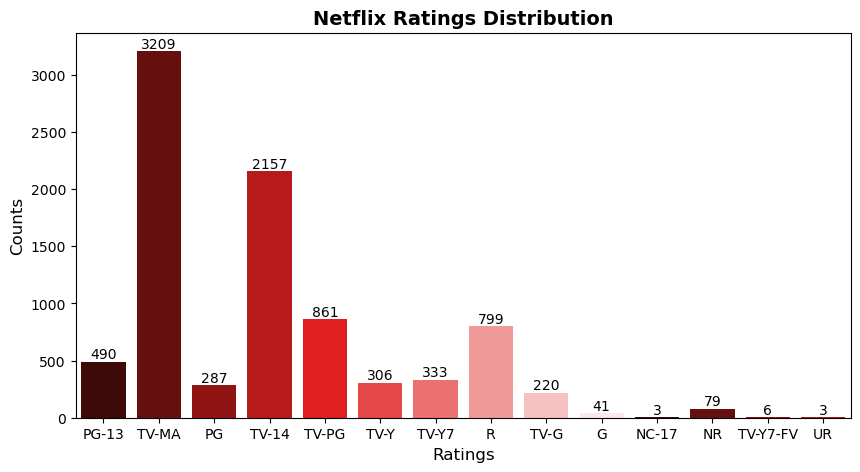

In [39]:
plt.figure(figsize= (10,5))

ax = sns.countplot(x = df_netflix['rating'] , palette = netflix_palette1)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height,
            str(int(height)),
            ha='center',
            va='bottom')

plt.title('Netflix Ratings Distribution', fontsize = 14 , fontweight = 'bold')
plt.xlabel('Ratings' , fontsize = 12)
plt.ylabel('Counts' , fontsize = 12)

plt.show()

### Insight
TV-MA is the most common rating

## Movie Duration Distribution
This section identifies ranges of movies duration.

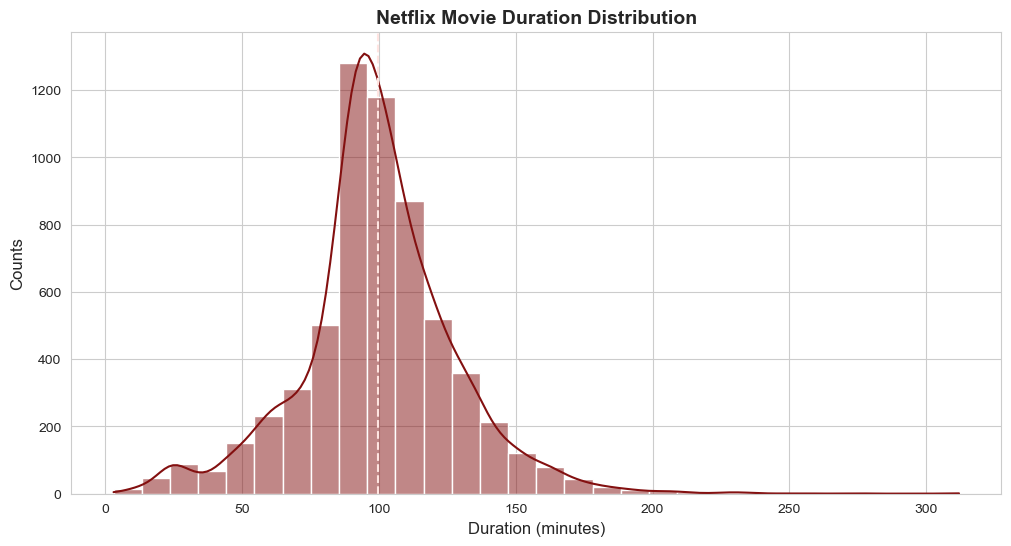

In [82]:
df_movies['duration_min'] = df_movies['duration'].str.replace(' min' ,'').astype(int)
avg = df_movies['duration_min'].mean()

plt.figure(figsize = (12,6))

sns.histplot(df_movies['duration_min'] ,bins = 30 , kde = True , color = '#831010')
plt.axvline(avg , linestyle = '--' , label = 'Average' , color = 'mistyrose')

plt.title('Netflix Movie Duration Distribution', fontsize = 14 , fontweight = 'bold')
plt.xlabel('Duration (minutes)' , fontsize = 12)
plt.ylabel('Counts' , fontsize = 12)

plt.show()

### Insight
Most movies are between 80–120 minutes

## Tv-shows overall Analysis
This section identifies ratings for netflix content.

In [30]:
country = df_movies.country.value_counts()[:5].reset_index()
country.columns = ['countries', 'count']
rating=df_movies.rating.value_counts()[:6].reset_index()
rating.columns=['ratings','count']

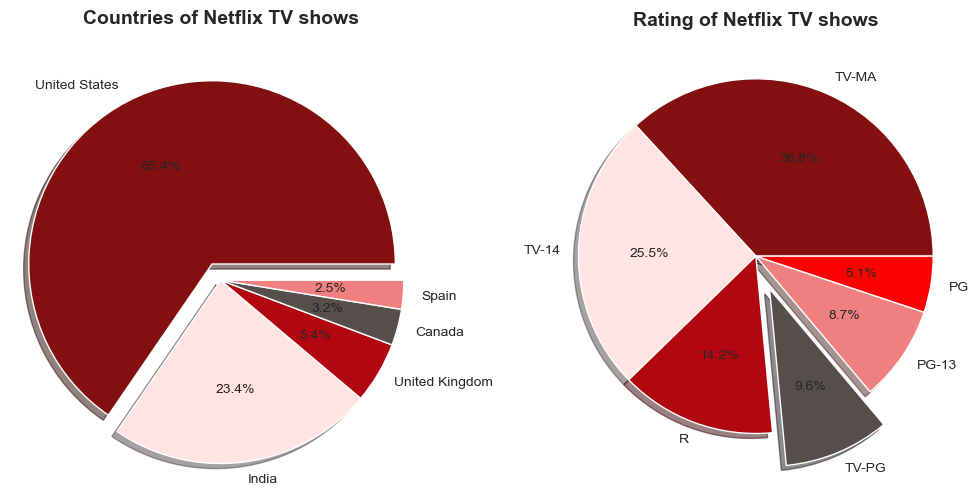

In [67]:
# Analysis for TV-shows
fig = plt.figure(figsize=(10,5))
gs = fig.add_gridspec(1,2)

ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])

ax0.text(0,1.4,"Countries of Netflix TV shows",fontsize=14,fontweight='bold',ha='center')
ax1.text(0,1.3,"Rating of Netflix TV shows",fontsize=14,fontweight='bold',ha='center')


ax0.pie(country['count'] , labels=country.countries, colors = netflix_palette2 , 
        explode = [0.1,0,0,0,0] , autopct = '%1.1f%%' , shadow = True)
ax1.pie(rating['count'], labels=rating.ratings, colors = netflix_palette2 ,
        explode = [0,0,0,0.2,0,0] , autopct = '%1.1f%%' , shadow = True)


ax0.axis('equal')
ax1.axis('equal')
plt.tight_layout()
plt.show()

### Insight
USA produces the most Netflix Tv-shows
TV-MA is the most common rating for Tv-shows

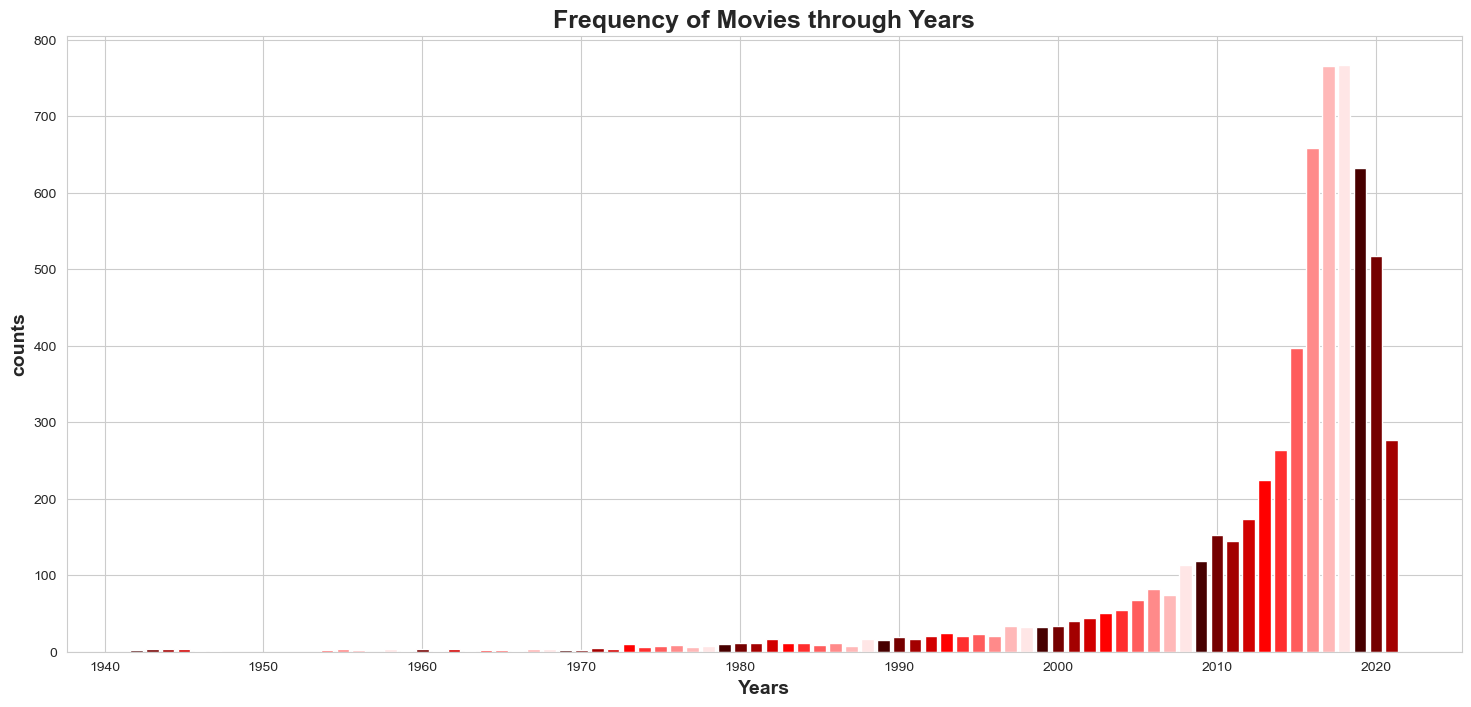

In [68]:
# Get Netflix Content through years in different way
year_counts = df_movies['release_year'].value_counts().sort_index()


fig , ax= plt.subplots(1,1 , figsize = (18,8))
ax.bar(year_counts.index , year_counts.values , color = netflix_palette1)


ax.set_xlabel('Years',fontsize = 14 , fontweight = 'bold')
ax.set_ylabel('counts',fontsize = 14 , fontweight = 'bold')
ax.set_title('Frequency of Movies through Years',fontsize = 18 , fontweight = 'bold')

plt.show()

### Insight
The number of content added to Netflix increased rapidly after 2015, reaching a peak in 2019

<div style="background-color: #C82909; 
            border-radius: 50px; 
            padding: 10px; 
            text-align: center; 
            font-family: 'Times New Roman', serif; 
            font-size: 30px; 
            color: white; 
            font-weight: normal;
            width: 80%;
    Final Conclusion
</div>

<div style="background-color: #C82909; 
            border-radius: 50px; 
            padding: 10px; 
            text-align: center; 
            font-family: 'Times New Roman', serif; 
            font-size: 30px; 
            color: white; 
            font-weight: normal;
            width: 80%;
            margin: auto;">
    Final Conclusion
</div>

## Final Conclusion

1. Netflix focuses mainly on movies.
2. USA is the largest content producer.
3. Platform growth accelerated after 2015.
4. Mature audience ratings dominate.
5. Most movies are medium length.